### Module 0: Configuration & Data Extraction

In [1]:
import os
import scanpy as sc
import pandas as pd
import numpy as np 
import matplotlib as plt

sc.settings.verbosity = 3           
sc.settings.datadir = 'data'      
sc.settings.figdir = 'figures'       
sc.settings.cachedir = 'data'   
sc.set_figure_params(dpi=100, color_map='viridis', format='png')

In [ ]:
adata = sc.read_10x_h5('data/M_Brain_Chromium_Nuc_Isolation_vs_SaltyEZ_vs_ComplexTissueDP_filtered_feature_bc_matrix.h5')
adata.var_names_make_unique()

### Module 1: Quality Check & Filtering of Low-Quality Data

In [ ]:
# Mitochondrial genes identification
genes_mt = [name for name in adata.var_names if 'mt-' in name.lower()]
print(f"Mitochondrial genes found: {genes_mt}")

Mitochondrial genes found: ['mt-Nd1', 'mt-Nd2', 'mt-Co1', 'mt-Co2', 'mt-Atp8', 'mt-Atp6', 'mt-Co3', 'mt-Nd3', 'mt-Nd4l', 'mt-Nd4', 'mt-Nd5', 'mt-Nd6', 'mt-Cytb']


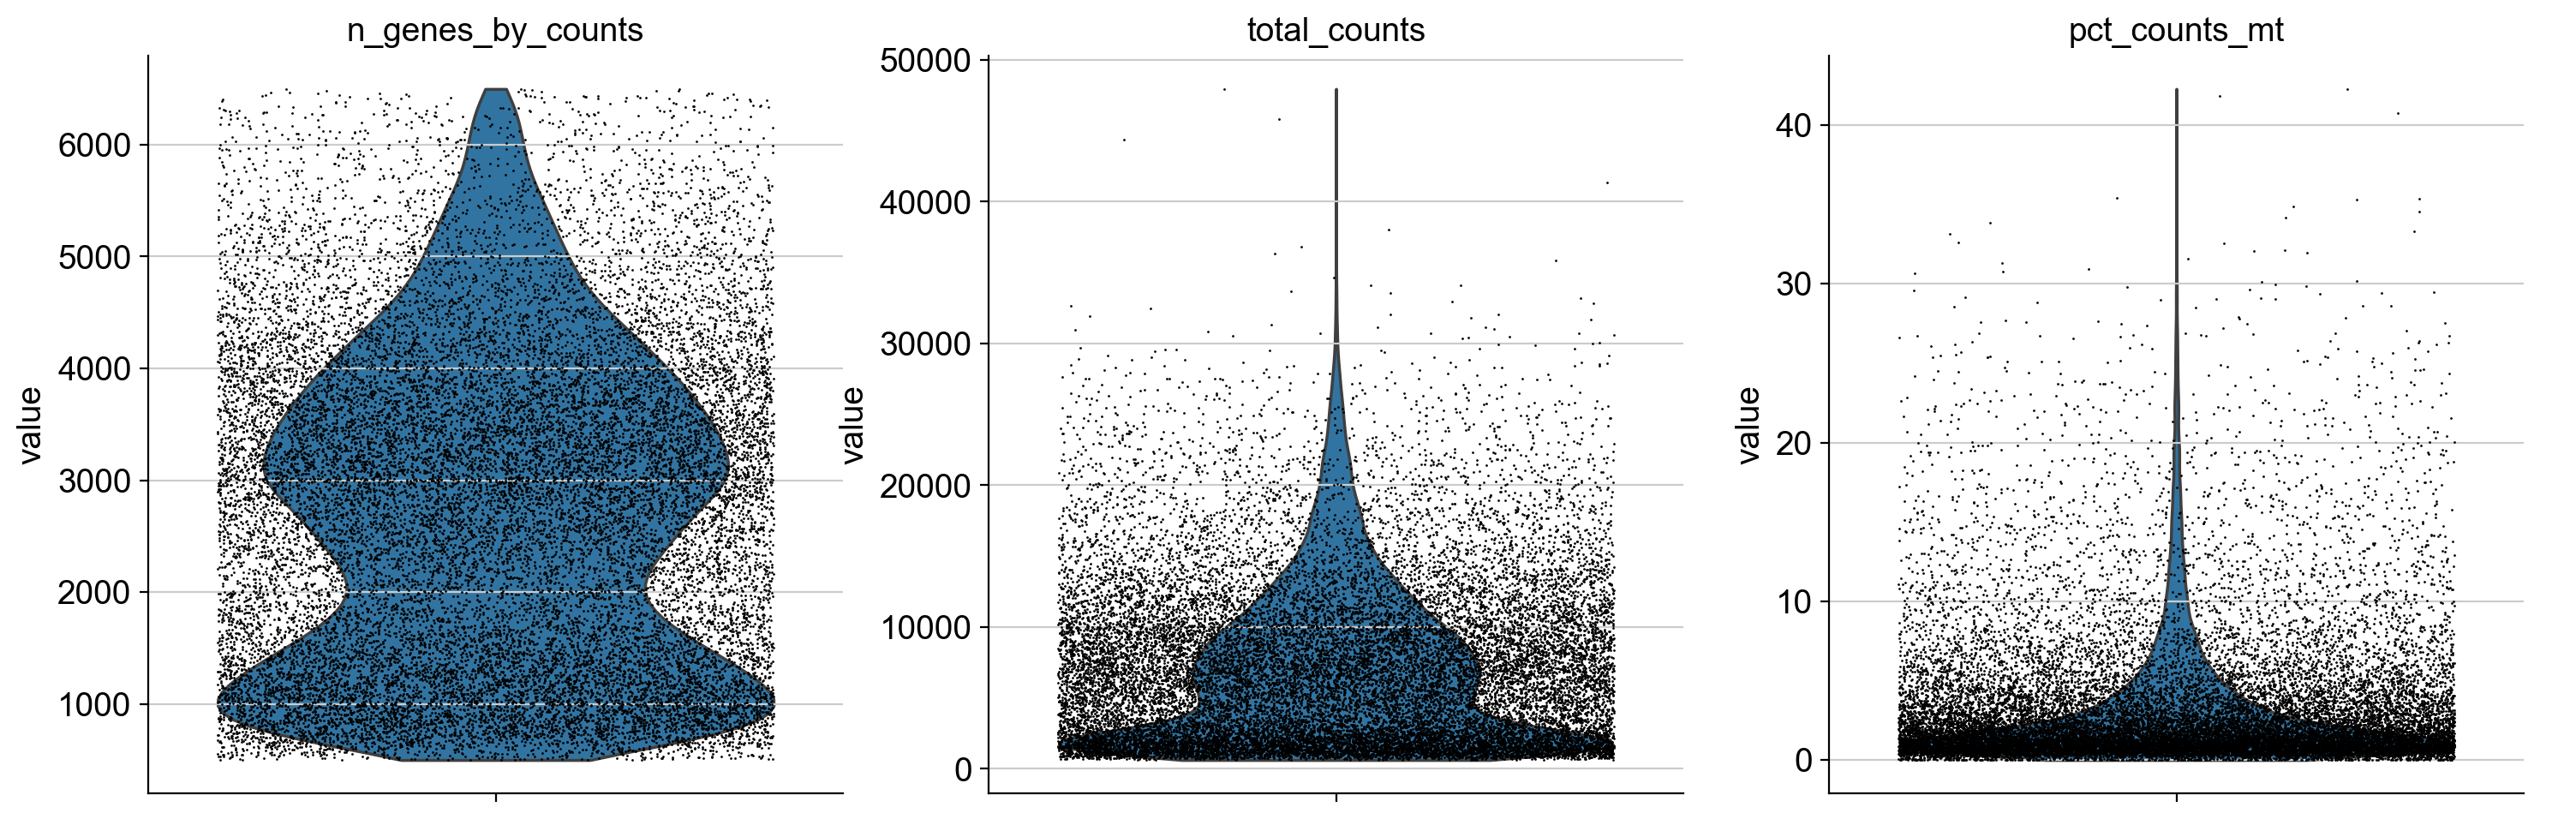

In [7]:
# Visualization of data metrics before the filtering to identify the outliers 

adata.var['mt'] = adata.var_names.str.lower().str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
             jitter=0.4, multi_panel=True, save='_qc_metrics.png')

In [ ]:
#Cell Filtering Strategy:
##- Remove low-quality cells and doublets
##- Filter cells with >5% mitochondrial content
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_cells(adata, max_genes=6500)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["total_counts"] >= 500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]
# Normalization of the data filtered
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)     
adata.raw = adata  
#Identify Highly Variable Genes to focus on biologically relevant signal 
#and reduce noise from housekeeping genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f"Genes highly variable: {adata.var['highly_variable'].sum()}")
adata = adata[:, adata.var["highly_variable"]]

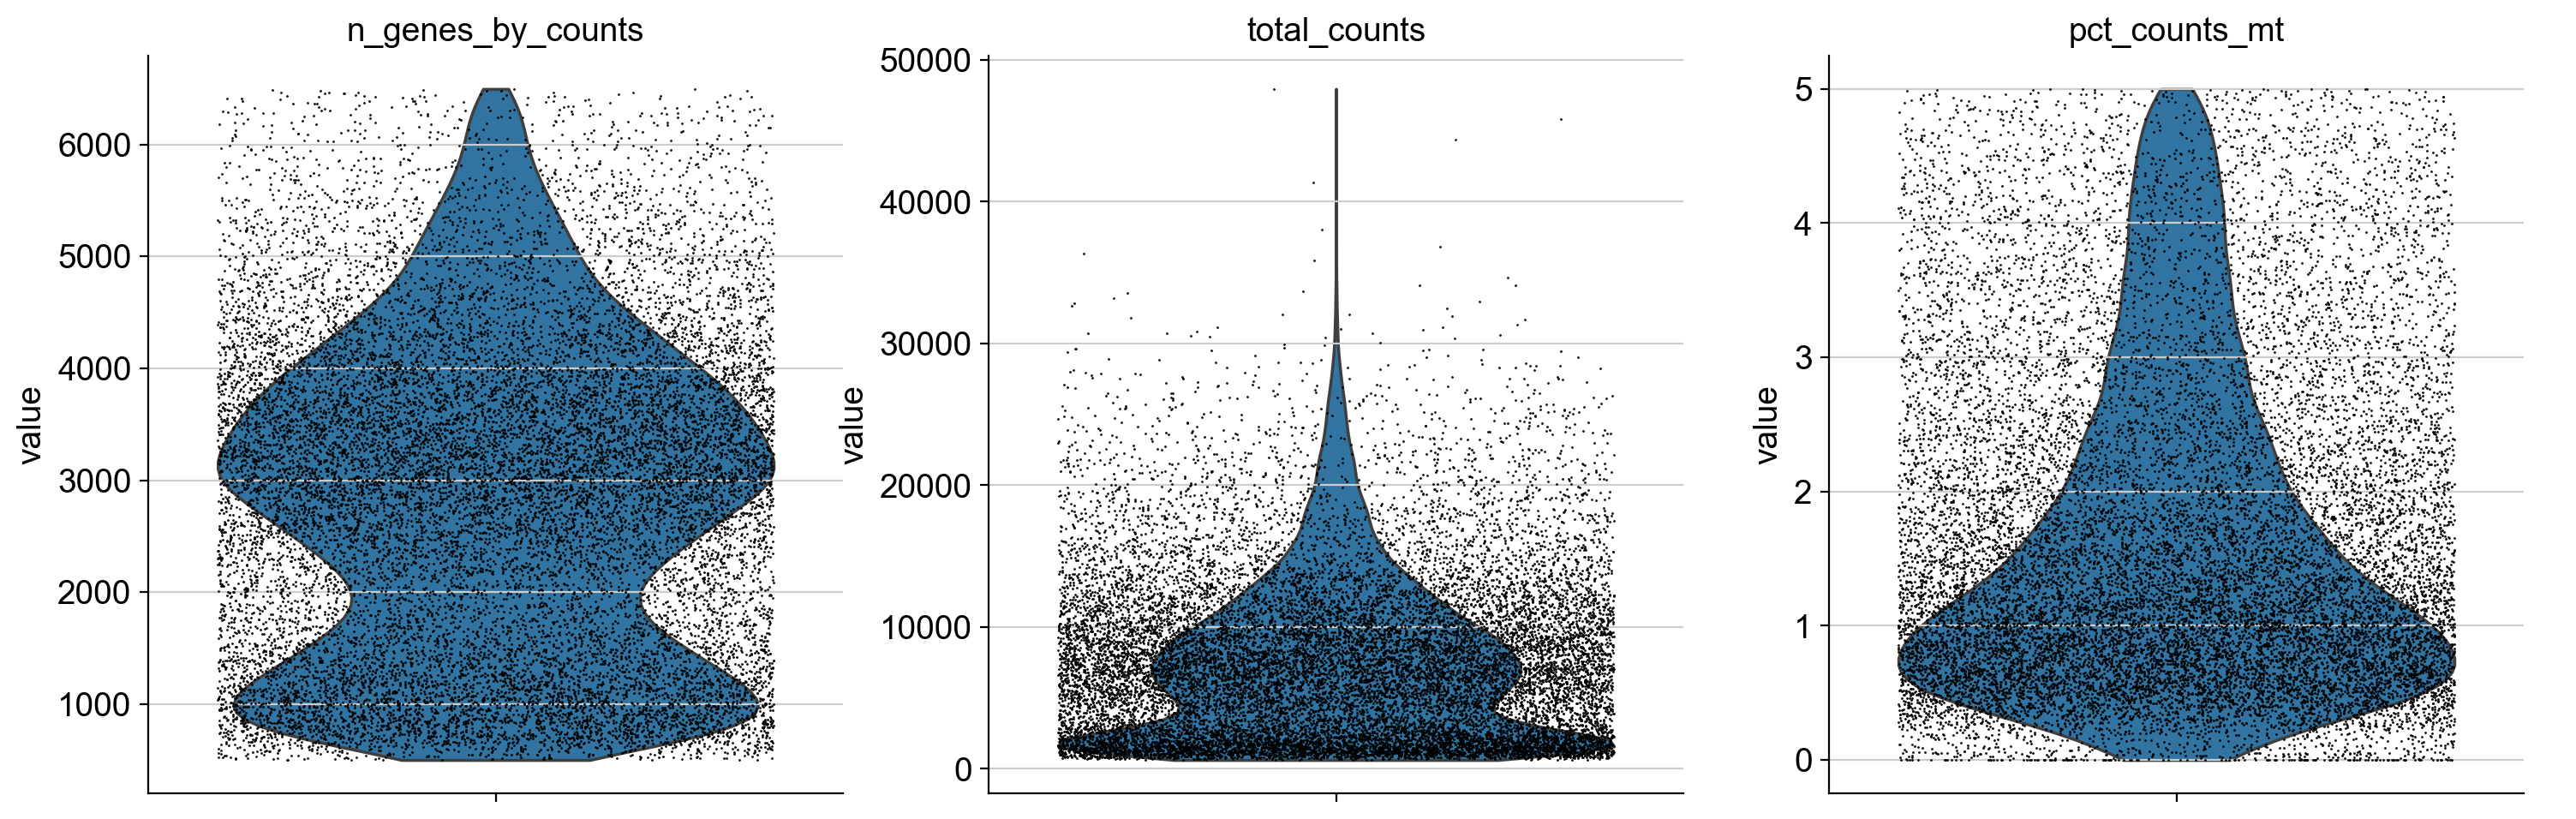

In [9]:
#Visualization of data metrics after the filtering
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
             jitter=0.4, 
             multi_panel=True, 
             save='_filtered.png')

### Module 2: Dimensionality reduction and clustering

regressing out ['total_counts', 'pct_counts_mt']


c:\Users\angel\miniconda3\envs\sc_env\Lib\site-packages\scanpy\preprocessing\_simple.py:728: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    sparse input is densified and may lead to high memory use
    finished (0:00:03)
computing PCA
    with n_comps=40
    finished (0:00:07)


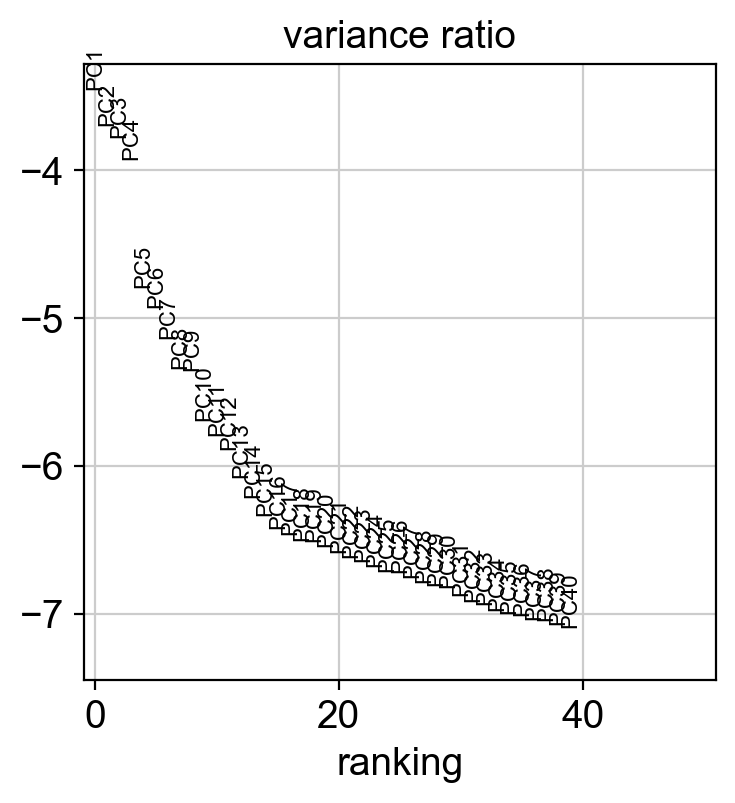

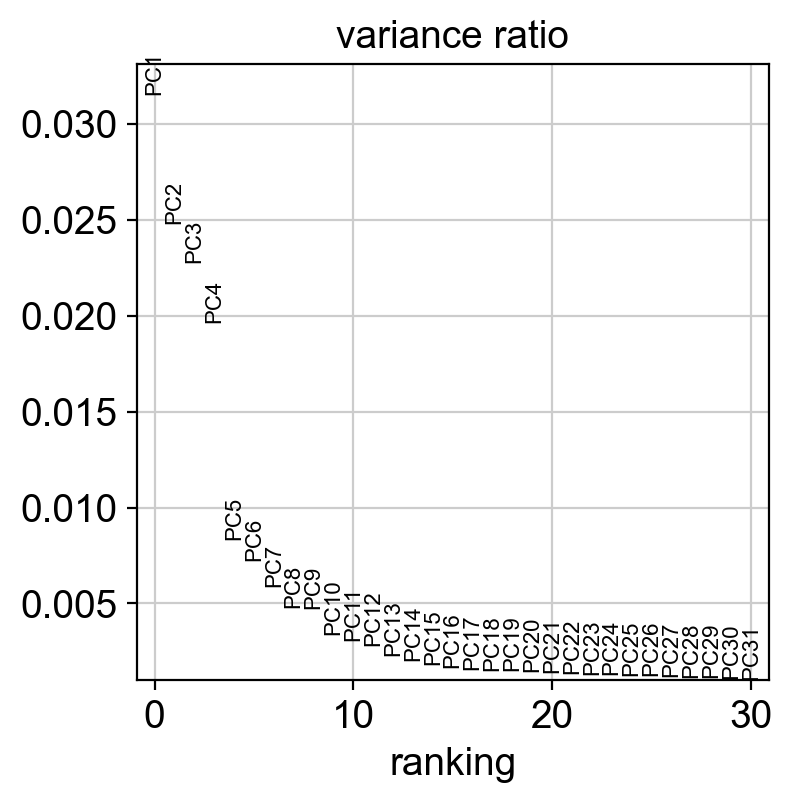

In [10]:
# Reduce the high-dimensional gene space into Principal Components
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack", n_comps=40)
# The elbow plot is used to determine the optimal number of Principal Components
# before the variance explained reaches a plateau
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, save='_elbow_plot.png')
sc.pl.pca_variance_ratio(adata, n_pcs=30, save='_elbow_plot_linear.png')

computing neighbors
    using 'X_pca' with n_pcs = 9
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:11)
running Leiden clustering
    finished: found 12 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)


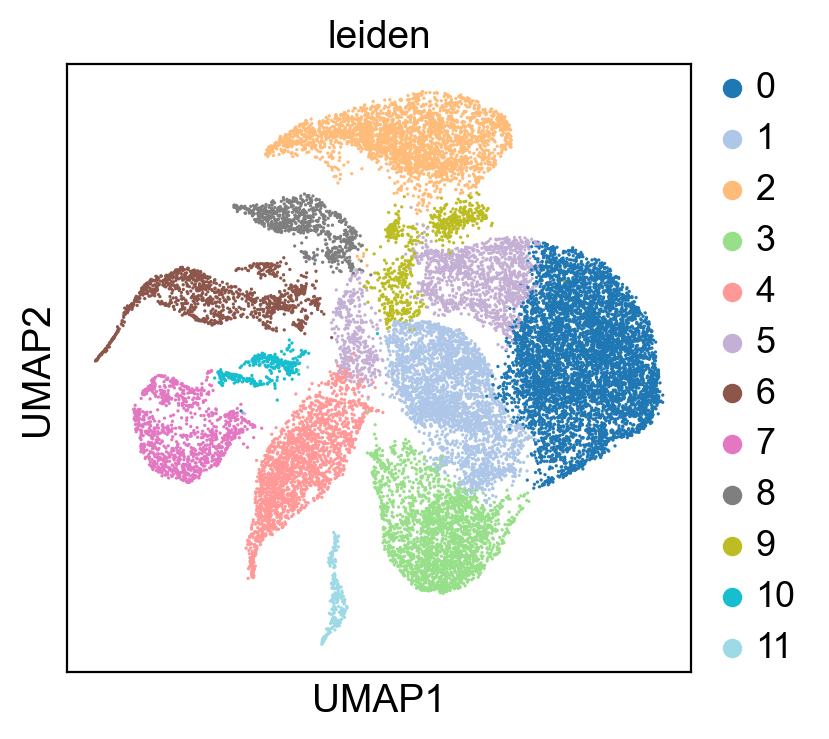

In [ ]:
# Compute the neighborhood graph using the top 9 PCs identified in the elbow plot  
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=9)
sc.tl.umap(adata)
# Set the leiden clustering to a resolution of 0.3 to avoid the overclustering 
# of the dataset
sc.tl.leiden(adata, resolution=0.3)
sc.pl.umap(adata, color=['leiden'], palette='tab20', save='_clusters.png')

### Module 4: Marker Gene Identification

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:19)


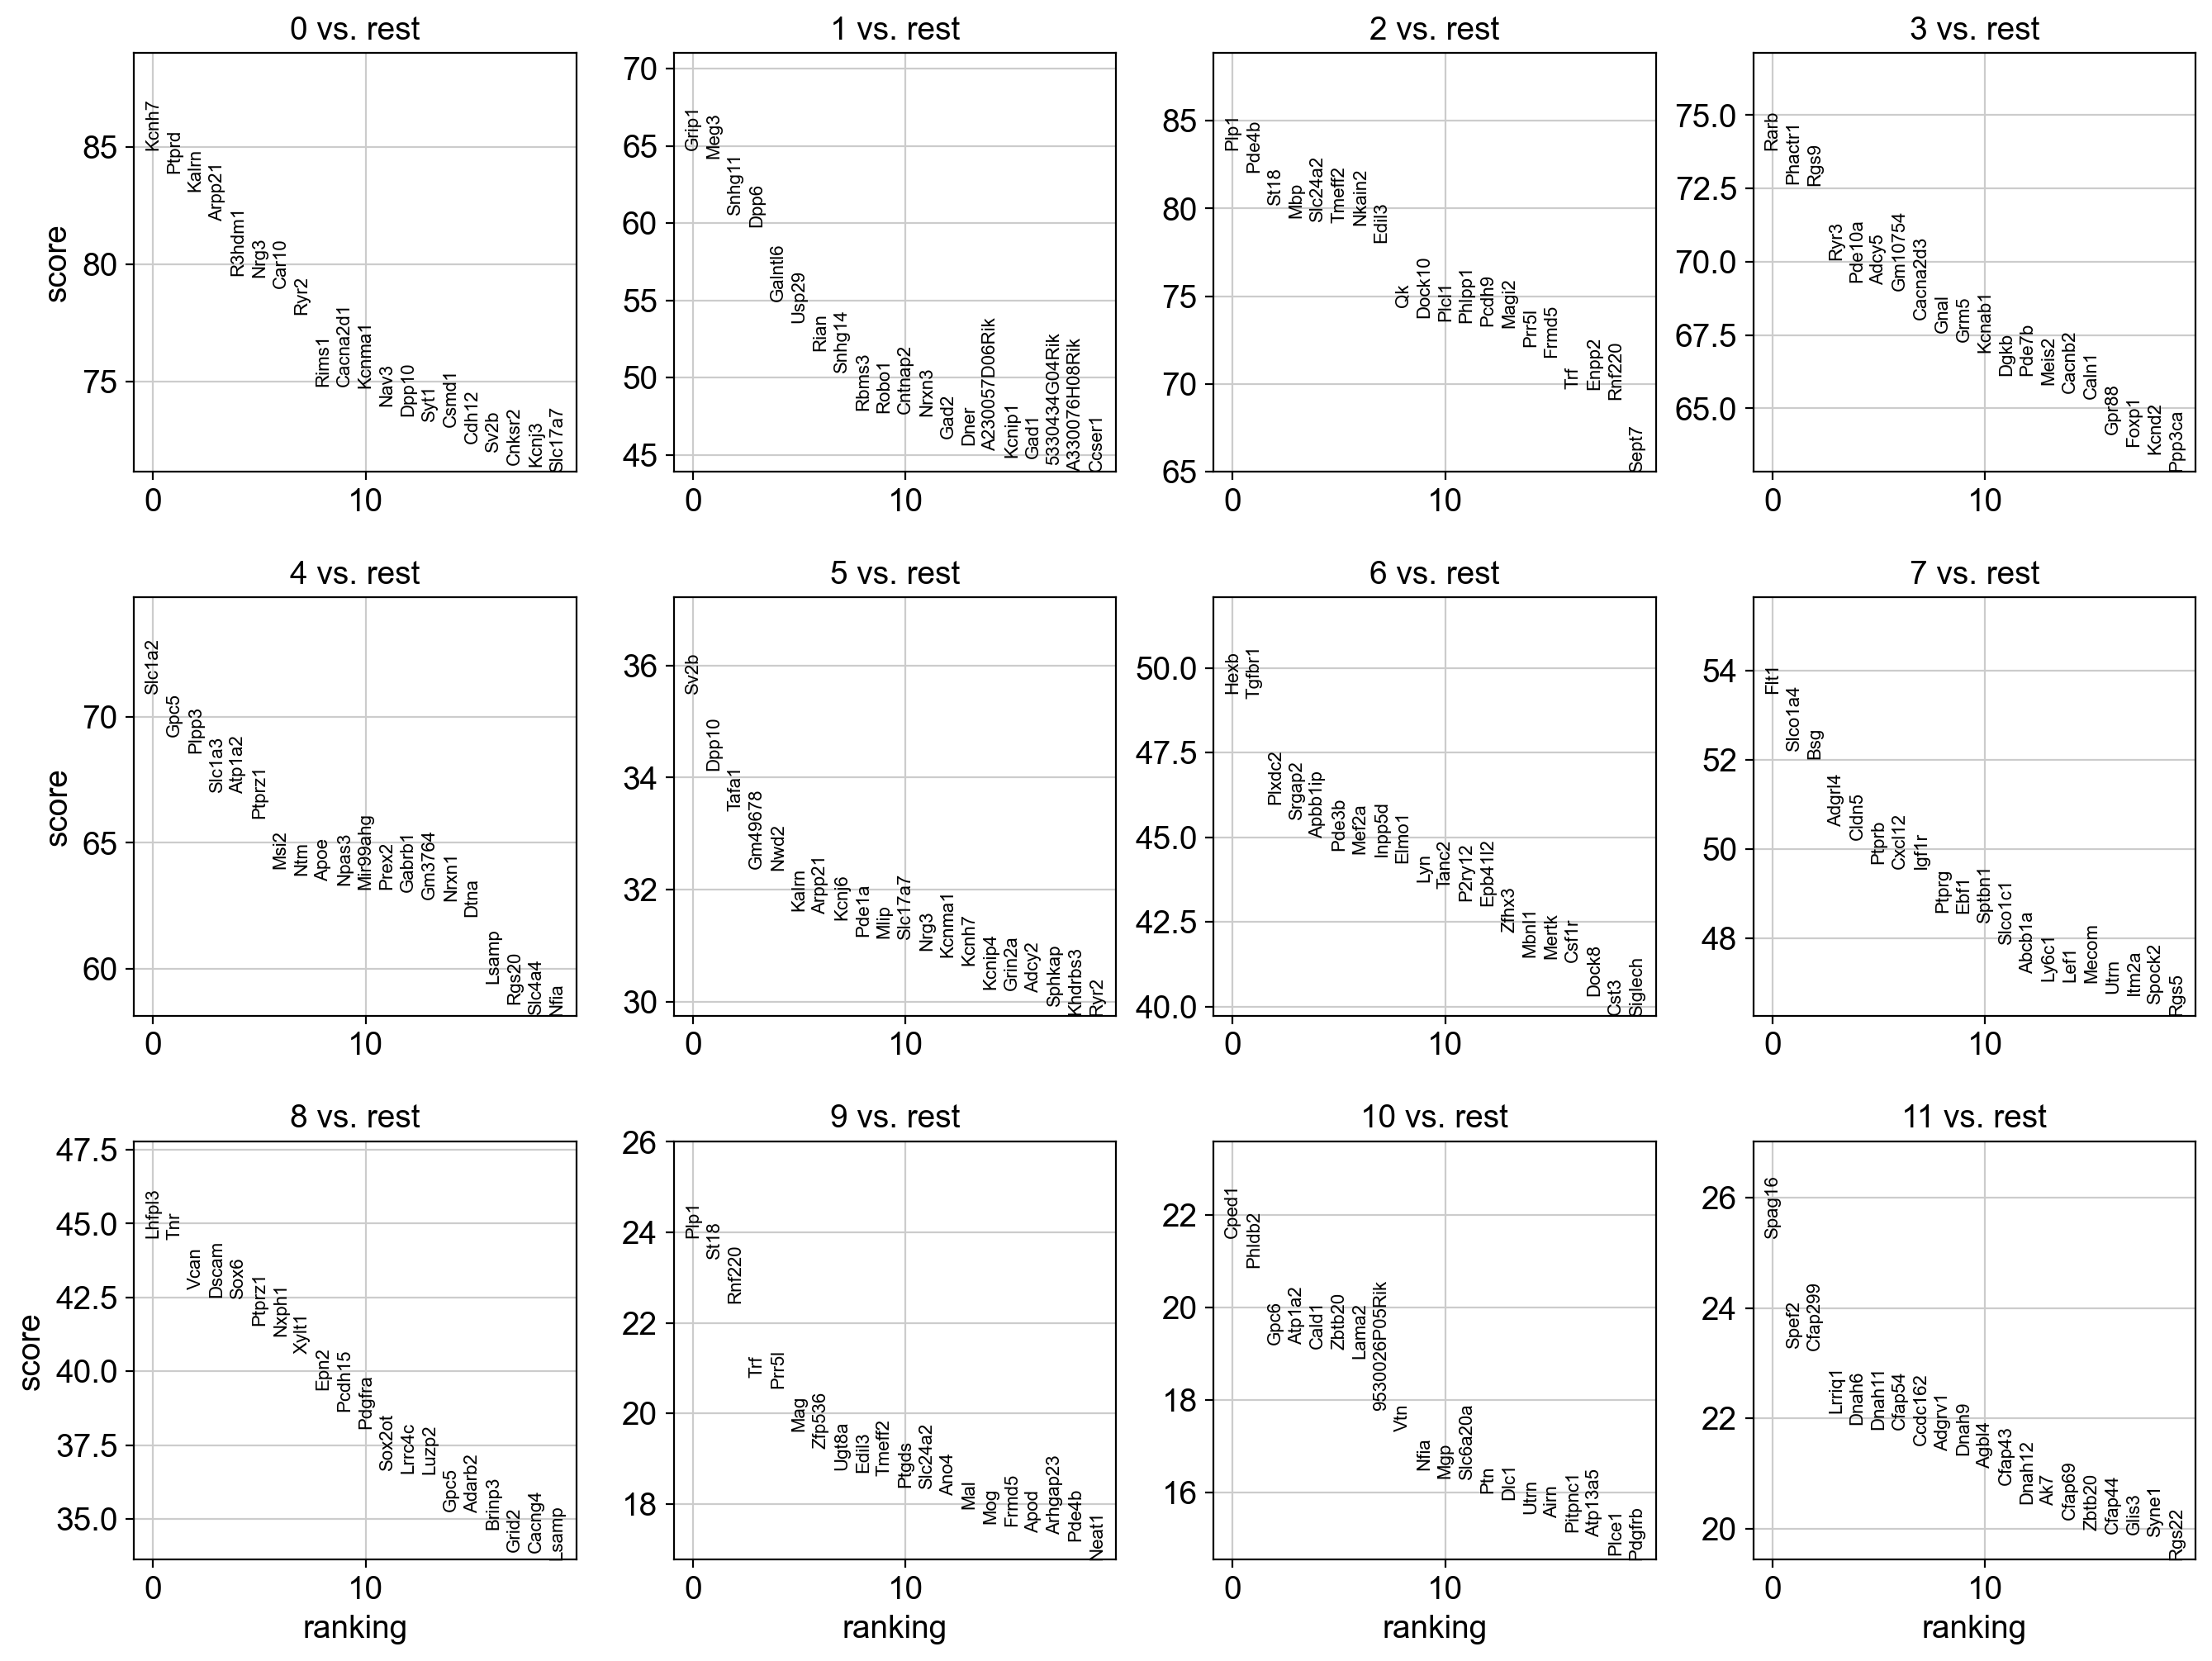

Genes marcadores encontrados:
          0        1        2         3       4        5        6        7  \
0     Kcnh7    Grip1     Plp1      Rarb  Slc1a2     Sv2b     Hexb     Flt1   
1     Ptprd     Meg3    Pde4b   Phactr1    Gpc5    Dpp10   Tgfbr1  Slco1a4   
2     Kalrn   Snhg11     St18      Rgs9   Plpp3    Tafa1   Plxdc2      Bsg   
3    Arpp21     Dpp6      Mbp      Ryr3  Slc1a3  Gm49678   Srgap2   Adgrl4   
4    R3hdm1  Galntl6  Slc24a2    Pde10a  Atp1a2     Nwd2  Apbb1ip    Cldn5   
5      Nrg3    Usp29   Tmeff2     Adcy5  Ptprz1    Kalrn    Pde3b    Ptprb   
6     Car10     Rian   Nkain2   Gm10754    Msi2   Arpp21    Mef2a   Cxcl12   
7      Ryr2   Snhg14    Edil3  Cacna2d3     Ntm    Kcnj6   Inpp5d    Igf1r   
8     Rims1    Rbms3       Qk      Gnal    Apoe    Pde1a    Elmo1    Ptprg   
9  Cacna2d1    Robo1   Dock10      Grm5   Npas3     Mlip      Lyn     Ebf1   

        8       9             10       11  
0  Lhfpl3    Plp1          Cped1   Spag16  
1     Tnr    St18      

In [ ]:
# Use the Wilcoxon rank-sum test to find genes diferentially expressed across
# the 12 clusters from the previous step. 
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False, save='_rank_genes.png')
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
# List the 10 most expressed genes of each cluster 
top_genes = pd.DataFrame(
    {group: result['names'][group] for group in groups}).head(10)
print("Genes marcadores encontrados:")
print(top_genes)

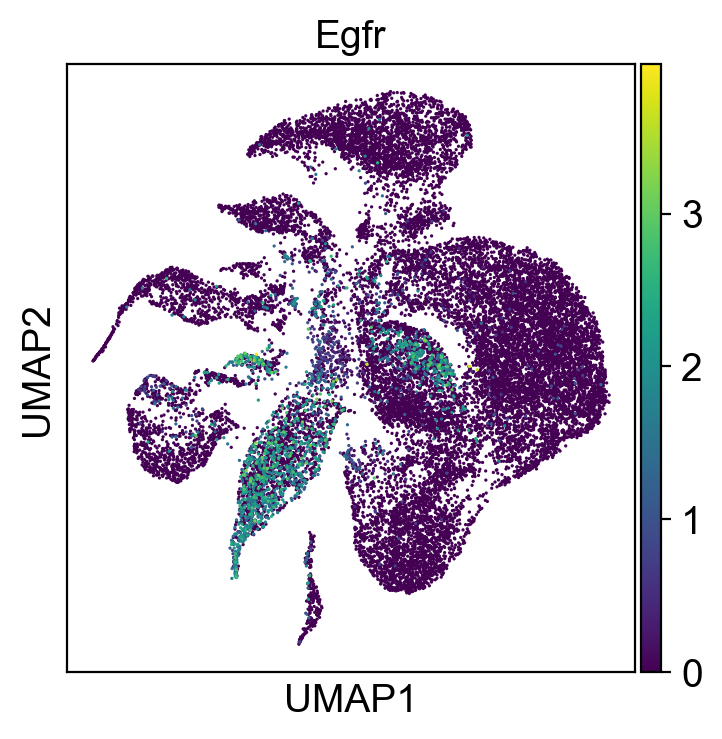

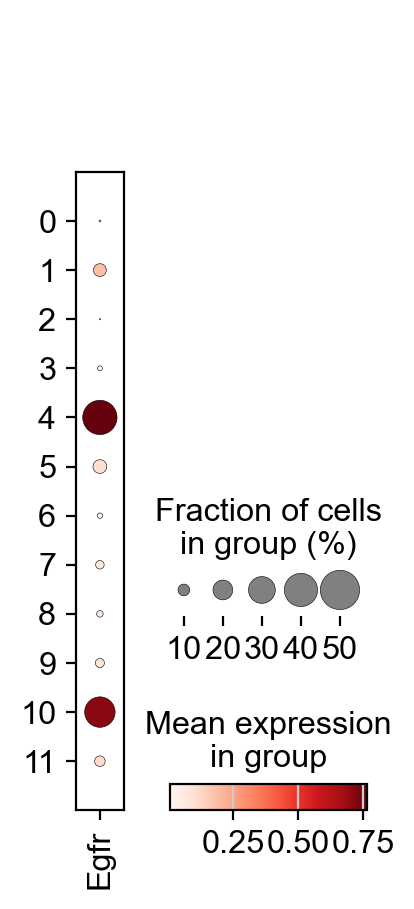

In [ ]:
# Mapping the specific gene of interest relevant to this dataset  
gene_of_interest = 'Egfr'
sc.pl.umap(adata, color=gene_of_interest, save=f'_{gene_of_interest}_expression.png')
sc.pl.dotplot(adata, [gene_of_interest], groupby='leiden', save=f'_{gene_of_interest}_preference.png')